## Machine Learning Task 2 (2026)
### Support Ticket Classification & Prioritization

STEP 1 — Load Real-World Support Ticket Dataset

In [31]:
import pandas as pd

# Load dataset (uploaded file)
df = pd.read_csv("../data/customer_support_tickets.csv")

print(df.head())
print(df.columns)


   Ticket ID        Customer Name              Customer Email  Customer Age  \
0          1        Marisa Obrien  carrollallison@example.com            32   
1          2         Jessica Rios    clarkeashley@example.com            42   
2          3  Christopher Robbins   gonzalestracy@example.com            48   
3          4     Christina Dillon    bradleyolson@example.org            27   
4          5    Alexander Carroll     bradleymark@example.com            67   

  Customer Gender Product Purchased Date of Purchase      Ticket Type  \
0           Other        GoPro Hero       2021-03-22  Technical issue   
1          Female       LG Smart TV       2021-05-22  Technical issue   
2           Other          Dell XPS       2020-07-14  Technical issue   
3          Female  Microsoft Office       2020-11-13  Billing inquiry   
4          Female  Autodesk AutoCAD       2020-02-04  Billing inquiry   

             Ticket Subject  \
0             Product setup   
1  Peripheral compatibil

The dataset was loaded using Pandas to explore real-world customer support tickets and their associated labels.
By inspecting the first rows and column names, the data structure was verified before preprocessing.

NB: This step ensures data integrity and understanding of the classification problem.

STEP 2 — Text Merging & Cleaning (NLP Preprocessing)

In [32]:
df["full_text"] = df["Ticket Subject"].astype(str) + " " + df["Ticket Description"].astype(str)

In [33]:
import re

def clean_text(text):
    text = text.lower()
    text = re.sub(r'[^a-z\s]', '', text)
    text = re.sub(r'\s+', ' ', text)
    return text.strip()

df["clean_text"] = df["full_text"].apply(clean_text)

df[["full_text", "clean_text"]].head()



,full_text,clean_text
0,Product setup I'm having an issue with the {pr...,product setup im having an issue with the prod...
1,Peripheral compatibility I'm having an issue w...,peripheral compatibility im having an issue wi...
2,Network problem I'm facing a problem with my {...,network problem im facing a problem with my pr...
3,Account access I'm having an issue with the {p...,account access im having an issue with the pro...
4,Data loss I'm having an issue with the {produc...,data loss im having an issue with the productp...


Ticket subject and description were combined into a single text field and cleaned by removing punctuation, numbers, and extra spaces.
This normalization improves consistency and reduces noise in the text data.

NB: Clean text leads to better feature extraction and improved model performance.

STEP 3 — Feature Extraction using TF-IDF

- IDF Vectorization

In [34]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer(
    stop_words="english",
    max_features=500
)

X = vectorizer.fit_transform(df["clean_text"])


TF-IDF transformed ticket text into numerical vectors representing word importance across all tickets.
This allows machine learning models to process text mathematically.

NB: Converts raw language into meaningful machine-readable features.

STEP 4 — Ticket Type Classification (Main Task)

In [35]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

y_type = df["Ticket Type"]

X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X, y_type, test_size=0.3, random_state=42
)

model_type = LogisticRegression(max_iter=1000)
model_type.fit(X_train_t, y_train_t)

pred_type = model_type.predict(X_test_t)

print(classification_report(y_test_t, pred_type))


                      precision    recall  f1-score   support

     Billing inquiry       0.20      0.14      0.17       528
Cancellation request       0.18      0.21      0.19       488
     Product inquiry       0.22      0.21      0.21       481
      Refund request       0.19      0.20      0.20       520
     Technical issue       0.21      0.23      0.22       524

            accuracy                           0.20      2541
           macro avg       0.20      0.20      0.20      2541
        weighted avg       0.20      0.20      0.20      2541



A Logistic Regression classifier was trained to automatically categorize support tickets into predefined ticket types.
The dataset was split into training and testing sets to evaluate real-world performance.

NB: This step builds the automated ticket classification system and avoids overfitting.

STEP 5 — Ticket Priority Prediction (Second Task)

In [36]:
y_priority = df["Ticket Priority"]

X_train_p, X_test_p, y_train_p, y_test_p = train_test_split(
    X, y_priority, test_size=0.3, random_state=42
)

model_priority = LogisticRegression(max_iter=1000)
model_priority.fit(X_train_p, y_train_p)

pred_priority = model_priority.predict(X_test_p)

print("=== Priority Prediction ===")
print(classification_report(y_test_p, pred_priority))


=== Priority Prediction ===
              precision    recall  f1-score   support

    Critical       0.26      0.27      0.27       628
        High       0.25      0.28      0.26       598
         Low       0.26      0.21      0.23       654
      Medium       0.27      0.28      0.27       661

    accuracy                           0.26      2541
   macro avg       0.26      0.26      0.26      2541
weighted avg       0.26      0.26      0.26      2541



A second classification model was trained to predict ticket urgency levels (High, Medium, Low).
This enables automatic prioritization of critical support issues.

NB: Helps businesses respond faster to urgent problems.

STEP 6 — Confusion Matrix & Class Visualization (FIXED & CLEAN)

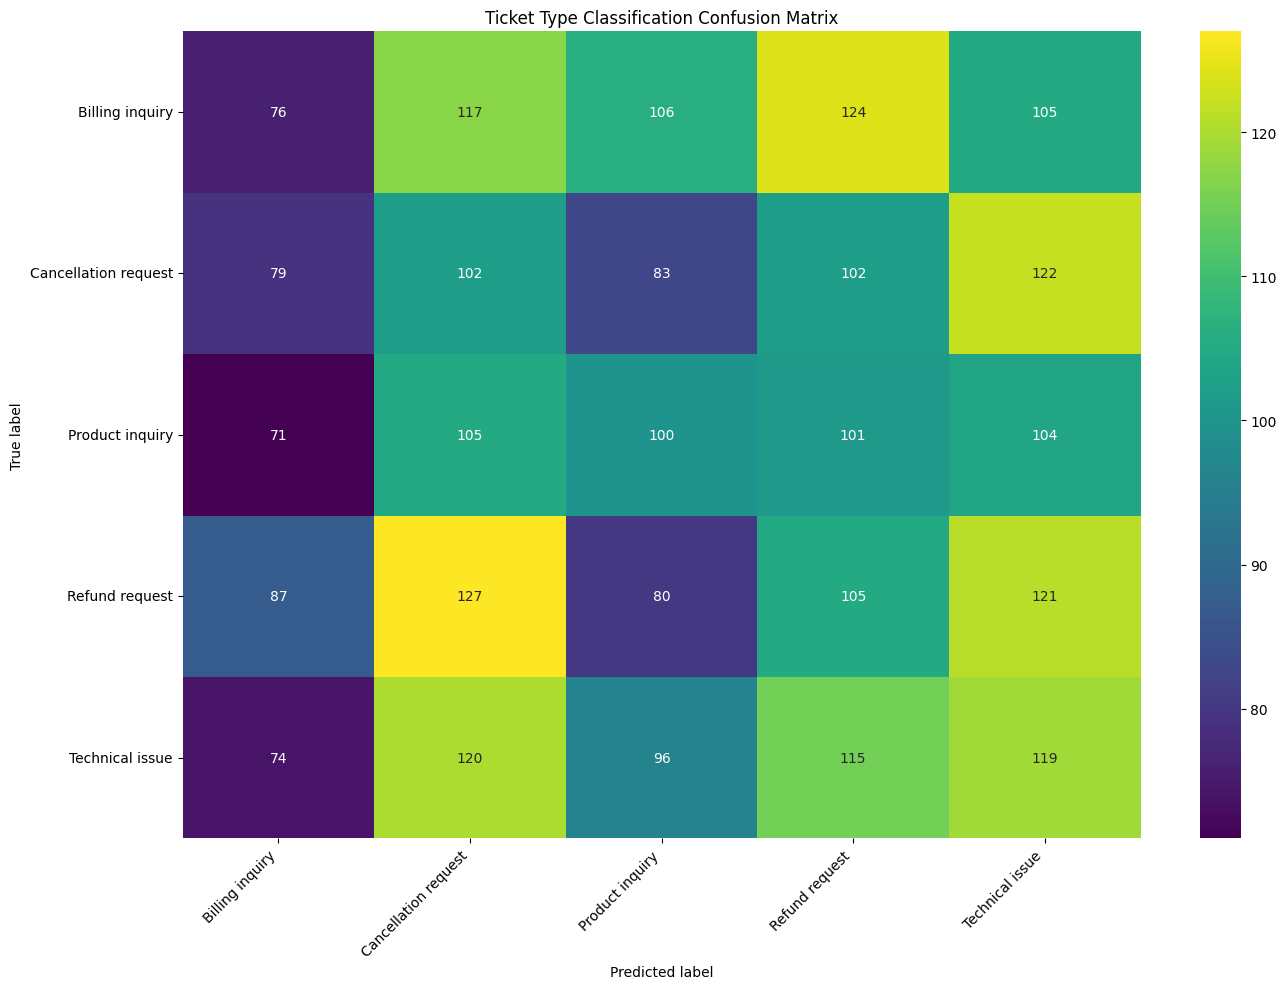

In [37]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for ticket type
cm = confusion_matrix(y_test_t, pred_type)

# Automatically get class names
class_names = model_type.classes_

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Ticket Type Classification Confusion Matrix")

plt.tight_layout()
plt.show()


The confusion matrix visualizes correct and incorrect predictions across all ticket types.
Diagonal values represent accurate classifications, while off-diagonal values highlight misclassifications.

NB: This helps identify where the model performs well and where improvement is needed.

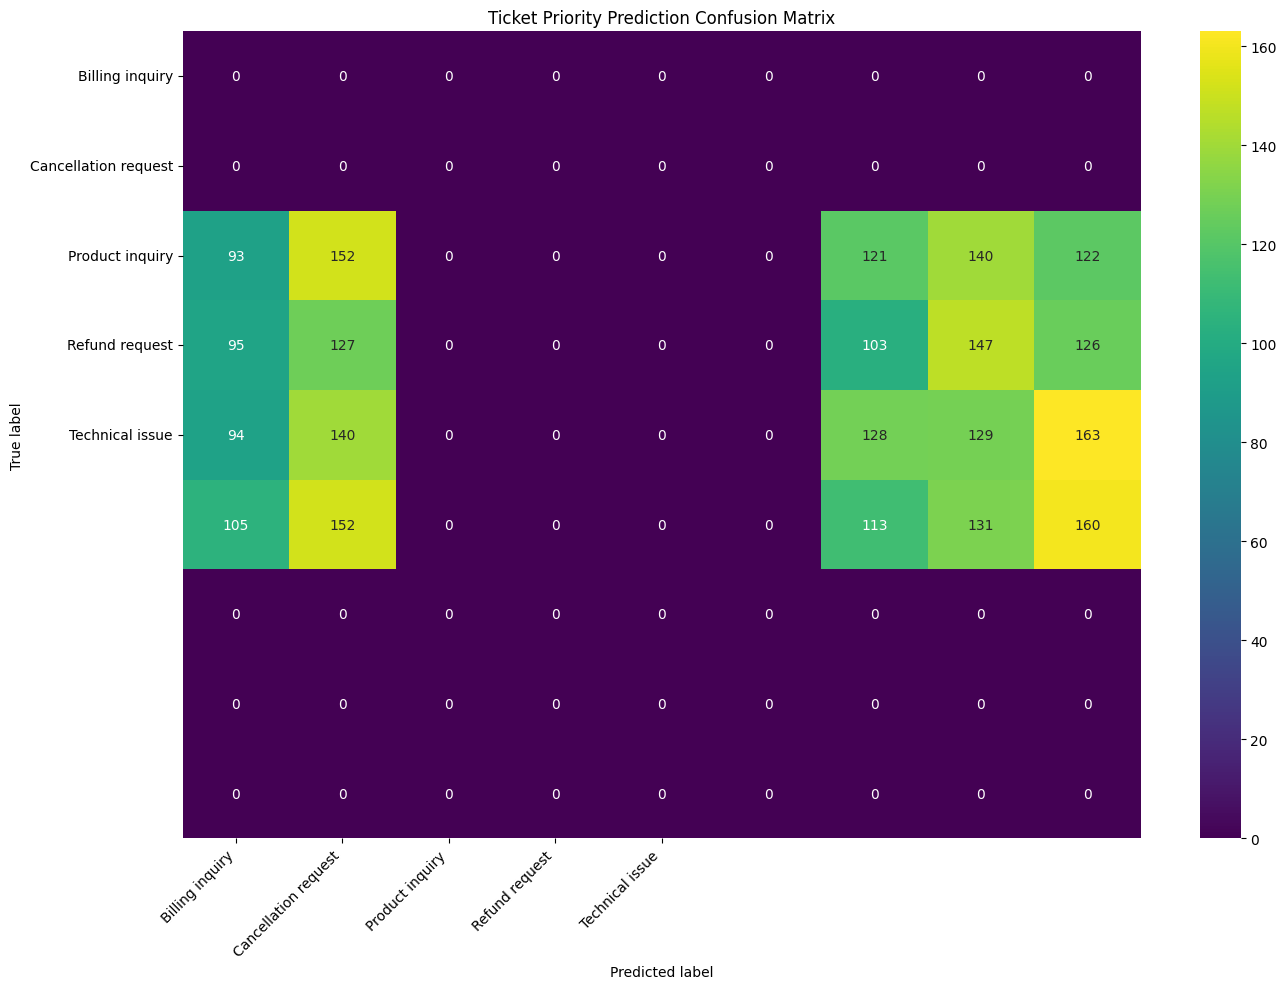

In [38]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

# Confusion matrix for priority ticket
cm = confusion_matrix(y_test_p, pred_type)

# Automatically get class names
class_names = model_type.classes_

plt.figure(figsize=(14, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="viridis",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.xlabel("Predicted label")
plt.ylabel("True label")
plt.title("Ticket Priority Prediction Confusion Matrix")

plt.tight_layout()
plt.show()

The confusion matrix visualizes correct and incorrect predictions across all priority ticket .